# Directional Command Recognition in Sinhala-English Speech Using DistilHuBERT Acoustic Features

A robust pipeline for recognizing directional commands (forward, backward, left, right, stop) in code-mixed Sinhala-English speech using state-of-the-art acoustic feature extraction (DistilHuBERT).


![Pipeline](../pipeline.png)

### Project Overview

### 🛠 System Architecture & Model Pipeline

#### 1. Pipeline Visualization
Below is a descriptive overview of the end-to-end pipeline for directional command recognition from raw audio:

1. **Audio Processing:**
   - The system begins with raw audio input, which undergoes preprocessing steps such as silence trimming and volume normalization to ensure consistent quality.
2. **Feature Extraction:**
   - The preprocessed audio is passed through the **DistilHuBERT** model. Unlike ASR, which converts speech to text, this captures the raw acoustic and phonetic patterns of the speech directly into high-dimensional vectors (768-D).
   - We apply **Mean Pooling** to condense the temporal sequence of vectors into a single representative acoustic embedding for the entire audio clip.
3. **Classification:**
   - The acoustic embedding is fed into a lightweight PyTorch MLP classifier. This neural network processes the embedding through Layer Normalization, Dropout, and a Hidden Layer with **GELU** activation to predict the most likely directional command (Forward, Backward, Left, Right, or Stop).

This pipeline ensures that the system can robustly handle noisy, code-mixed speech and accurately map spoken commands to actionable directions without the overhead or errors of an intermediate ASR step.

#### 2. Core Model Concepts (Layer Format)

| **Component** | **Model/Layer Type** | **Key Function** |
| :--- | :--- | :--- |
| **Feature Extractor** | **DistilHuBERT** | Extracts high-dimensional acoustic features directly from raw audio waveforms, capturing phonetic nuances without needing transcription. |
| **Pooling** | **Mean Pooling** | Compresses the variable-length sequence of hidden states into a single 768-dimensional vector representing the entire utterance. |
| **Classifier** | **Layer Normalization** | Standardizes the 768-D input features to improve training stability and convergence speed. |
| **Classifier** | **Input Dropout (20%)** | Randomly masks input features to force the model to learn redundant and robust acoustic patterns. |
| **Classifier** | **Hidden Layer** | Maps features to a 256-unit space using **GELU** activation for advanced non-linear modeling. |
| **Classifier** | **Hidden Dropout (40%)** | Stronger regularization to prevent overfitting on low-resource voice data. |
| **Classifier** | **Output Layer** | Maps the learned features to one of the five directional command classes. |


### Environment Setup

In [1]:
!pip install transformers datasets torchaudio librosa tqdm matplotlib seaborn scikit-learn soundfile


In [2]:
import os
import glob
import pandas as pd
import numpy as np
import librosa
import librosa.display
import torch
import torchaudio
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from tqdm.auto import tqdm
import random

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")

Using device: cuda


## step 1: Data Acquisition & Preprocessing

*The foundation of the pipeline. Poor audio quality will cascade into the feature extractor and ruin the acoustic embeddings.*

1. **Dataset Compilation:** Gather `.wav` files for the 5 directional classes (backward, forward, left, right, stop) in code-mixed Sinhala-English formats.
2. 💡 **Crucial Addition - Train/Val/Test Split:** You **must** split your raw audio files into Training (e.g., 70%), Validation (15%), and Test (15%) sets *before* doing any feature extraction. This prevents "data leakage" (accidentally testing on data the model has seen).
3. **Silence Trimming:** Remove dead air at the beginning and end of the audio clips.
4. 💡 **Crucial Addition - Volume Normalization:** Standardize the decibel level across all files. If some files are too quiet, the acoustic features might be poorly represented.

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# 1.1 Dataset Compilation
DATA_DIR = "/content/drive/MyDrive/2nd Year Research Data/Directions"
LABELS = ["backward", "forward", "left", "right", "stop"]

data = []
for label in LABELS:
    path = os.path.join(DATA_DIR, label)
    if not os.path.exists(path):
        print(f"Warning: Path {path} does not exist.")
        continue
    files = glob.glob(os.path.join(path, "*.wav"))
    for f in files:
        data.append({"path": f, "label": label})

df = pd.DataFrame(data)
print(f"Total samples found: {len(df)}")

Total samples found: 380


### 1.3 Silence Trimming & Volume Normalization

In [5]:
import soundfile as sf
import os

def preprocess_audio(file_path):
    """Applies trimming and normalization to a single audio file."""
    y, sr = librosa.load(file_path, sr=16000)
    y_trimmed, _ = librosa.effects.trim(y, top_db=20)
    y_norm = librosa.util.normalize(y_trimmed)
    return y_norm, sr

if not df.empty:
    preprocessed_audio_dir = "/content/drive/MyDrive/2nd Year Research Data/Preprocessed_Audio"
    os.makedirs(preprocessed_audio_dir, exist_ok=True)

    processed_paths = []
    for idx, row in tqdm(df.iterrows(), total=len(df), desc="Preprocessing Audio"):
        filename = os.path.basename(row['path'])
        label_subdir = os.path.join(preprocessed_audio_dir, row['label'])
        os.makedirs(label_subdir, exist_ok=True)
        new_path = os.path.join(label_subdir, filename)

        # Check if the file already exists to avoid redundant processing
        if os.path.exists(new_path):
            processed_paths.append(new_path)
        else:
            try:
                y_proc, sr = preprocess_audio(row['path'])
                sf.write(new_path, y_proc, sr)
                processed_paths.append(new_path)
            except Exception as e:
                print(f" [Error] Failed to process {row['path']}: {e}")
                processed_paths.append(row['path']) # Fallback to original path if processing fails

    df['path'] = processed_paths
    print(f"Preprocessed paths updated for {len(df)} samples.")

Preprocessing Audio:   0%|          | 0/380 [00:00<?, ?it/s]

Preprocessed paths updated for 380 samples.


## step 2: Exploratory Data Analysis (EDA)

*Proving you understand the data before modeling it.*

1. **Class Imbalance Check:** Generate histograms to prove each of the 5 directions has roughly the same number of samples.
2. **Acoustic Visualization:** Generate and display Mel-spectrograms for a few samples to show the acoustic differences between English and Sinhala commands.
3. 💡 **Crucial Addition - Audio Length Distribution:** Plot a histogram of audio durations (e.g., most clips are 1.5 to 2.5 seconds). This justifies your real-time processing window later.

/tmp/ipykernel_2961/2178915580.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_plot, x='label', palette='viridis')


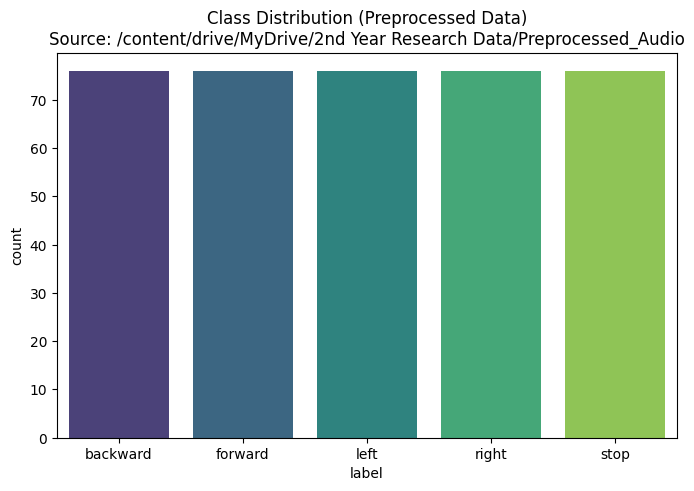

Total preprocessed samples found: 380


In [6]:
import glob

# Ensure we check the preprocessed directory
preprocessed_audio_dir = "/content/drive/MyDrive/2nd Year Research Data/Preprocessed_Audio"

# Re-scan the preprocessed directory to ensure the plot reflects the actual processed files
preprocessed_data = []
for label in LABELS:
    label_path = os.path.join(preprocessed_audio_dir, label)
    if os.path.exists(label_path):
        files = glob.glob(os.path.join(label_path, "*.wav"))
        for f in files:
            preprocessed_data.append({"path": f, "label": label})

if preprocessed_data:
    df_plot = pd.DataFrame(preprocessed_data)
    plt.figure(figsize=(8, 5))
    sns.countplot(data=df_plot, x='label', palette='viridis')
    plt.title(f"Class Distribution (Preprocessed Data)\nSource: {preprocessed_audio_dir}")
    plt.show()
    print(f"Total preprocessed samples found: {len(df_plot)}")
else:
    print(f"[Error] No preprocessed audio found in {preprocessed_audio_dir}. Please run the preprocessing step first.")

Calculating durations... this may take a moment.


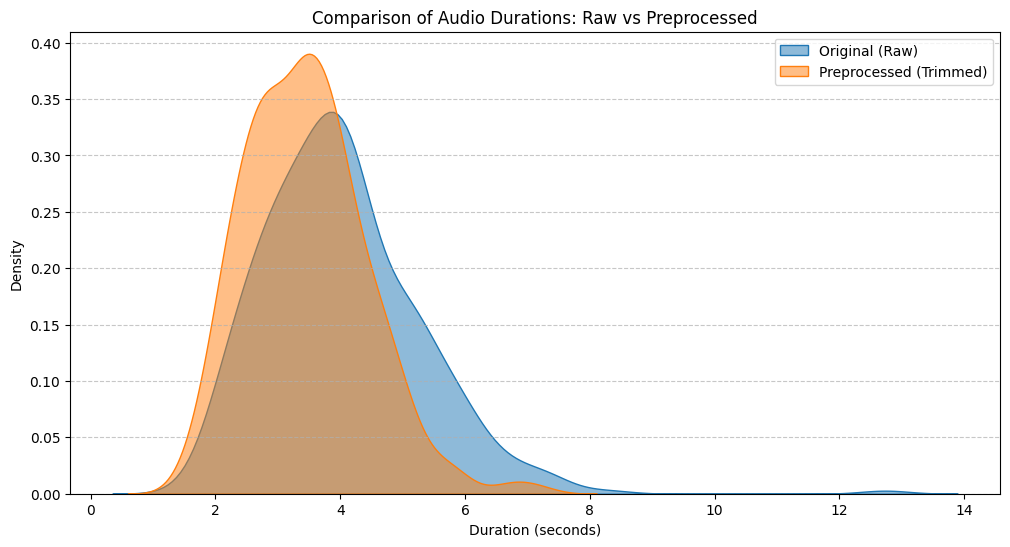


--- Duration Statistics Comparison ---
       Metric  Raw Data (s)  Preprocessed (s)
Mean Duration      4.017678           3.43834
 Min Duration      1.509250           1.47725
 Max Duration     12.736000           7.23200
Total Samples    380.000000         380.00000

Average reduction per file: 0.58s (due to silence trimming)


In [7]:
# 2.2 Audio Length Distribution Comparison (Before vs After Preprocessing)
import os
import librosa
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import glob
import numpy as np

raw_audio_dir = "/content/drive/MyDrive/2nd Year Research Data/Directions"
preprocessed_audio_dir = "/content/drive/MyDrive/2nd Year Research Data/Preprocessed_Audio"
LABELS = ["backward", "forward", "left", "right", "stop"]

def get_durations(base_dir):
    durations = []
    for label in LABELS:
        label_path = os.path.join(base_dir, label)
        if os.path.exists(label_path):
            files = glob.glob(os.path.join(label_path, "*.wav"))
            for f in files:
                try:
                    dur = librosa.get_duration(path=f)
                    durations.append(dur)
                except:
                    continue
    return durations

print("Calculating durations... this may take a moment.")
raw_durations = get_durations(raw_audio_dir)
proc_durations = get_durations(preprocessed_audio_dir)

if raw_durations and proc_durations:
    plt.figure(figsize=(12, 6))

    # Plotting comparison
    sns.kdeplot(raw_durations, label="Original (Raw)", fill=True, alpha=0.5)
    sns.kdeplot(proc_durations, label="Preprocessed (Trimmed)", fill=True, alpha=0.5)

    plt.title("Comparison of Audio Durations: Raw vs Preprocessed")
    plt.xlabel("Duration (seconds)")
    plt.ylabel("Density")
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

    # Display Stats
    stats_df = pd.DataFrame({
        "Metric": ["Mean Duration", "Min Duration", "Max Duration", "Total Samples"],
        "Raw Data (s)": [np.mean(raw_durations), np.min(raw_durations), np.max(raw_durations), len(raw_durations)],
        "Preprocessed (s)": [np.mean(proc_durations), np.min(proc_durations), np.max(proc_durations), len(proc_durations)]
    })

    print("\n--- Duration Statistics Comparison ---")
    print(stats_df.to_string(index=False))

    reduction = np.mean(raw_durations) - np.mean(proc_durations)
    print(f"\nAverage reduction per file: {reduction:.2f}s (due to silence trimming)")
else:
    print("[Error] Could not find audio in one of the directories. Please check your Drive paths.")

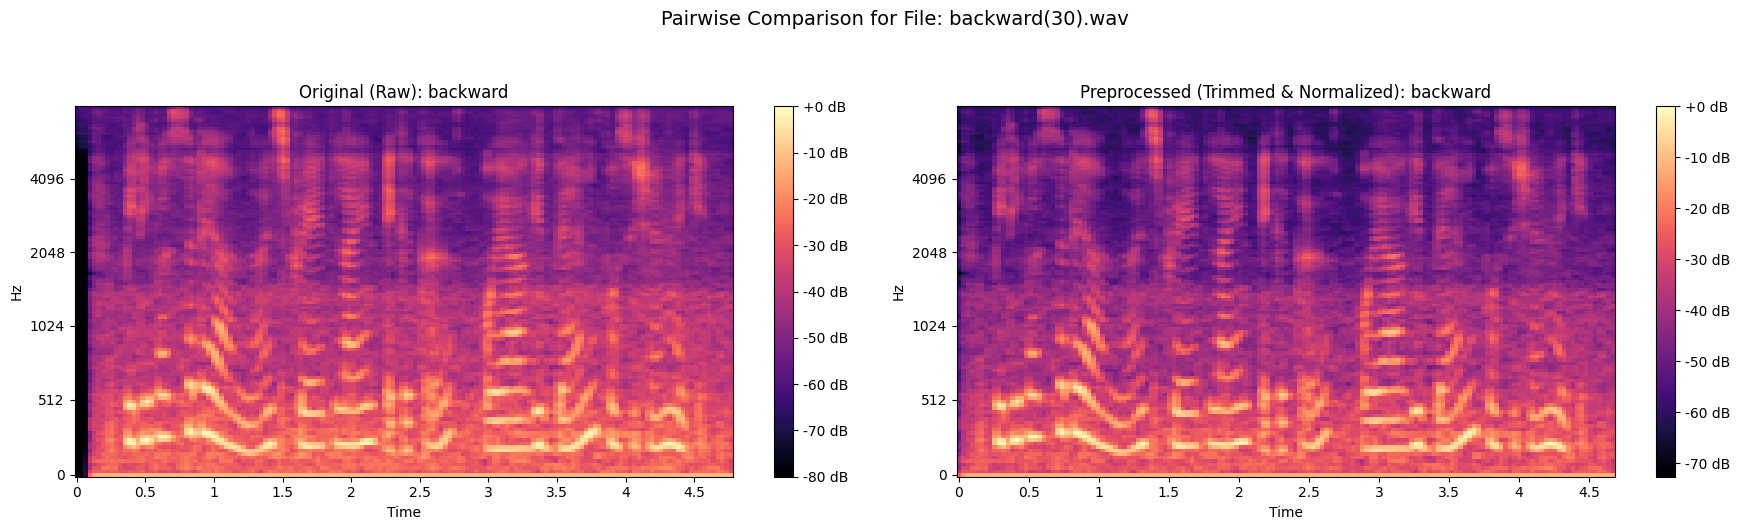

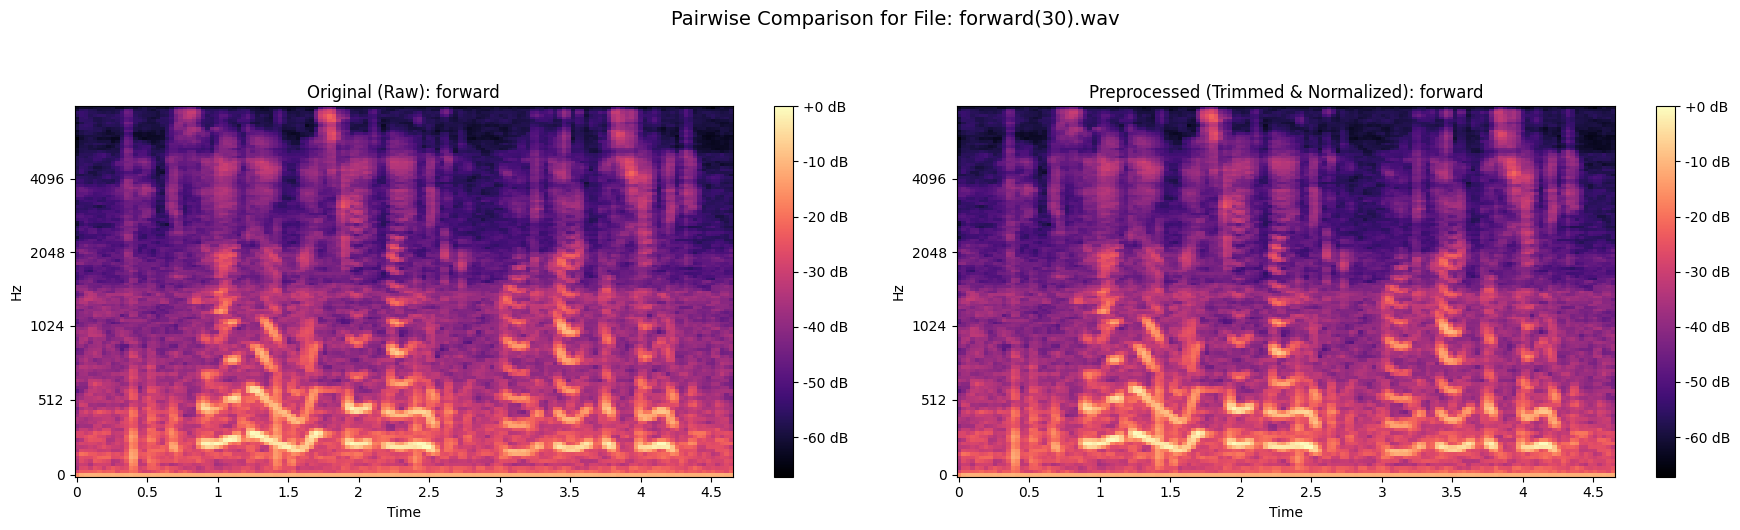

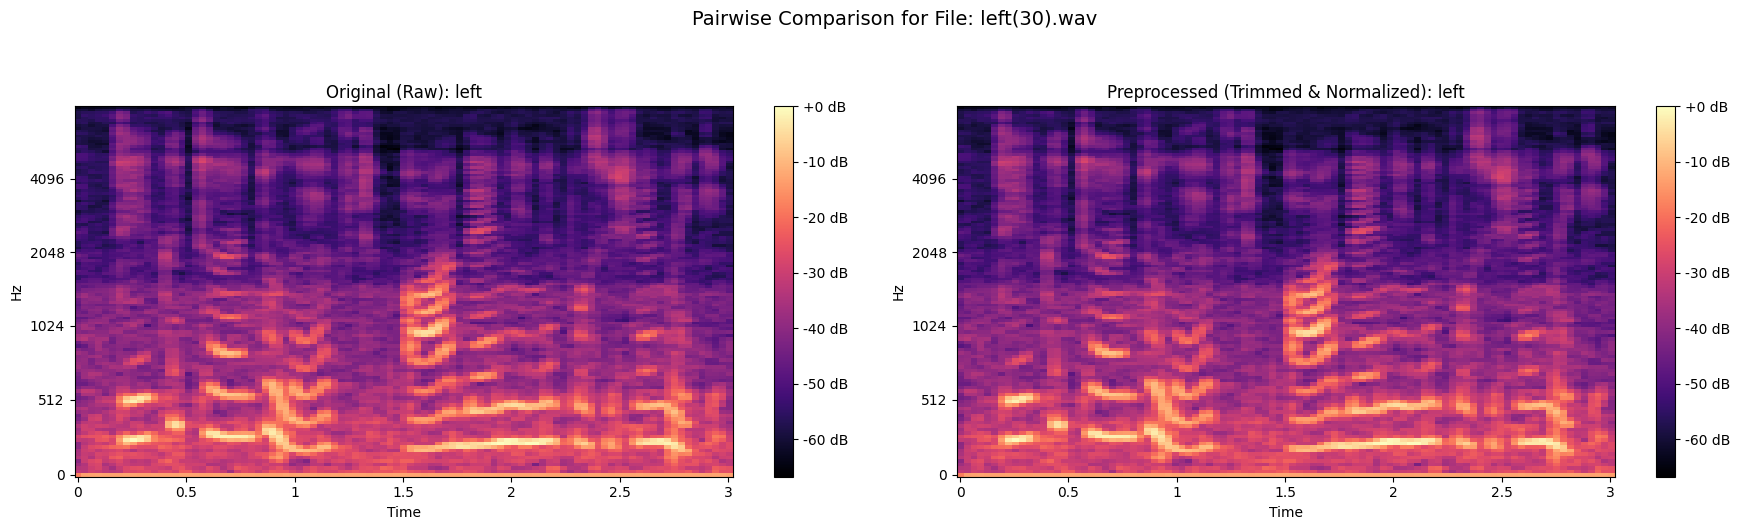

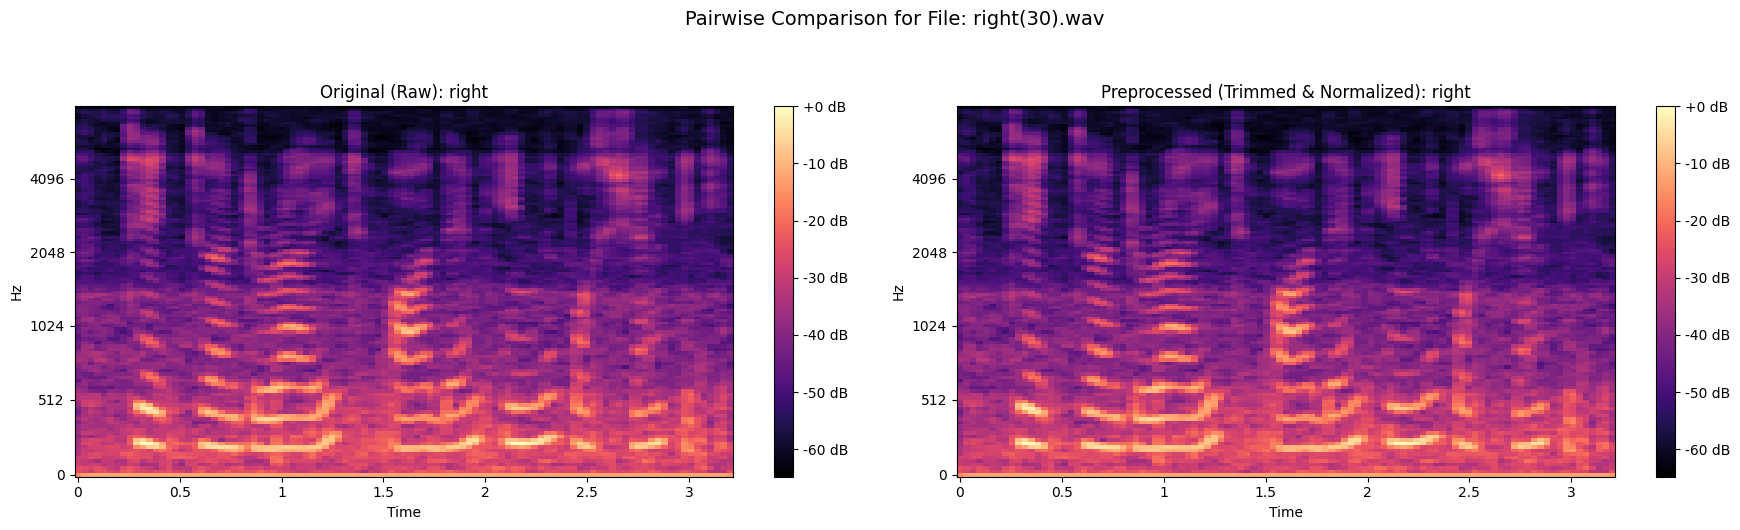

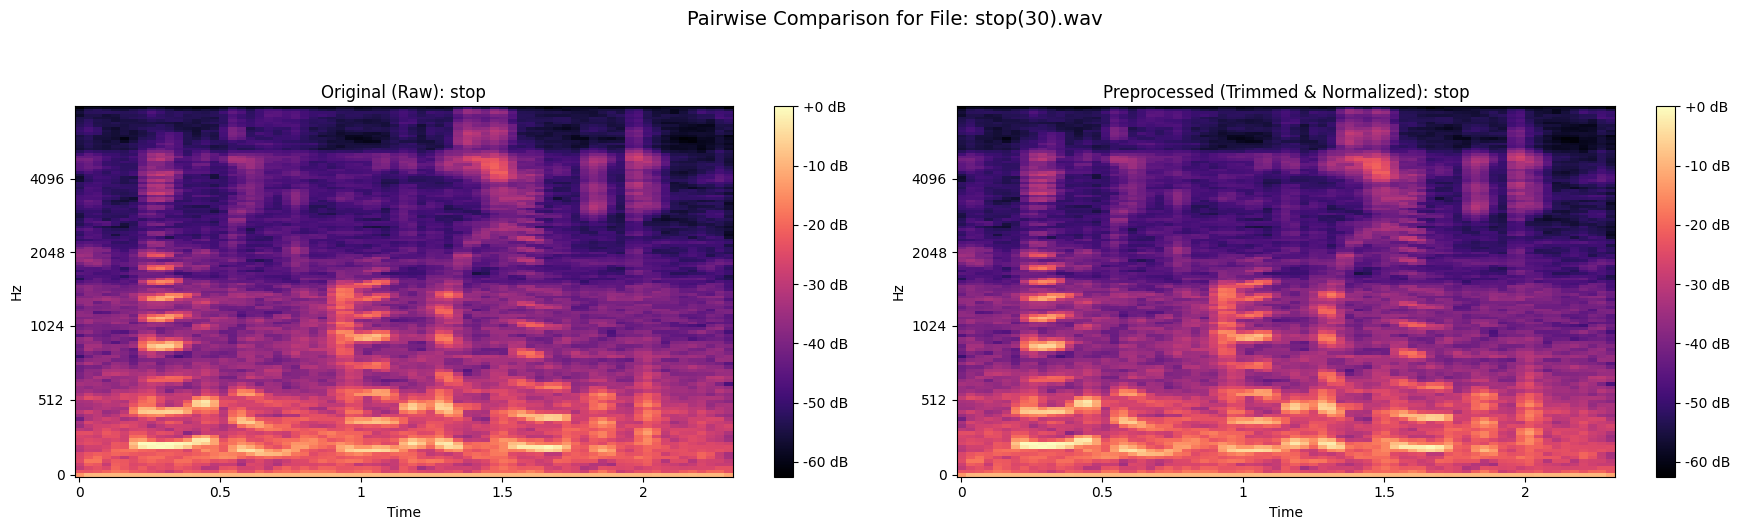

In [8]:
# 2.3 Acoustic Visualization: Before vs After Preprocessing (Pairwise Comparison)
import glob
import os
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt

def compare_mel_spectrograms(raw_path, proc_path, label):
    # Adjusted to 1 row and 2 columns for horizontal positioning
    fig, axes = plt.subplots(1, 2, figsize=(18, 5))

    # Raw Plot (Left)
    y_raw, sr = librosa.load(raw_path, sr=16000)
    S_raw = librosa.feature.melspectrogram(y=y_raw, sr=sr, n_mels=128)
    S_dB_raw = librosa.power_to_db(S_raw, ref=np.max)
    img1 = librosa.display.specshow(S_dB_raw, x_axis='time', y_axis='mel', sr=sr, ax=axes[0])
    axes[0].set_title(f"Original (Raw): {label}")
    fig.colorbar(img1, ax=axes[0], format='%+02.0f dB')

    # Preprocessed Plot (Right)
    y_proc, sr = librosa.load(proc_path, sr=16000)
    S_proc = librosa.feature.melspectrogram(y=y_proc, sr=sr, n_mels=128)
    S_dB_proc = librosa.power_to_db(S_proc, ref=np.max)
    img2 = librosa.display.specshow(S_dB_proc, x_axis='time', y_axis='mel', sr=sr, ax=axes[1])
    axes[1].set_title(f"Preprocessed (Trimmed & Normalized): {label}")
    fig.colorbar(img2, ax=axes[1], format='%+02.0f dB')

    plt.suptitle(f"Pairwise Comparison for File: {os.path.basename(raw_path)}", fontsize=14, y=1.05)
    plt.tight_layout()
    plt.show()

raw_audio_dir = "/content/drive/MyDrive/2nd Year Research Data/Directions"
preprocessed_audio_dir = "/content/drive/MyDrive/2nd Year Research Data/Preprocessed_Audio"

# Visualize one sample for each label side-by-side
for label in LABELS:
    proc_label_path = os.path.join(preprocessed_audio_dir, label)
    if os.path.exists(proc_label_path):
        proc_files = glob.glob(os.path.join(proc_label_path, "*.wav"))
        if proc_files:
            filename = os.path.basename(proc_files[0])
            raw_file_path = os.path.join(raw_audio_dir, label, filename)

            if os.path.exists(raw_file_path):
                compare_mel_spectrograms(raw_file_path, proc_files[0], label)
            else:
                print(f"[Warn] Could not find raw counterpart for {filename}")

In [9]:
# 1.2 Train/Val/Test Split
if not df.empty:
    # Ensure we are using the preprocessed directory
    preprocessed_audio_dir = "/content/drive/MyDrive/2nd Year Research Data/Preprocessed_Audio"

    # Update the dataframe paths to point to the preprocessed versions if they exist
    def update_to_preprocessed_path(row):
        filename = os.path.basename(row['path'])
        new_path = os.path.join(preprocessed_audio_dir, row['label'], filename)
        return new_path if os.path.exists(new_path) else row['path']

    df['path'] = df.apply(update_to_preprocessed_path, axis=1)

    # Perform the split on the updated paths
    train_df, temp_df = train_test_split(df, test_size=0.3, random_state=SEED, stratify=df['label'])
    val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=SEED, stratify=temp_df['label'])

    output_dir = "/content/drive/MyDrive/2nd Year Research Data/Data"
    os.makedirs(output_dir, exist_ok=True)
    train_df.to_csv(os.path.join(output_dir, 'train_df.csv'), index=False)
    val_df.to_csv(os.path.join(output_dir, 'val_df.csv'), index=False)
    test_df.to_csv(os.path.join(output_dir, 'test_df.csv'), index=False)

    print(f"Split complete using data from: {preprocessed_audio_dir}")
    print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")

Split complete using data from: /content/drive/MyDrive/2nd Year Research Data/Preprocessed_Audio
Train: 266, Val: 57, Test: 57


## step 3: Feature Extraction (The NO-ASR Acoustic Bridge)

*Converting raw audio directly into high-dimensional acoustic representations using Self-Supervised Learning (SSL).*

1. **Acoustic Feature Extraction:** Pass the preprocessed 16kHz audio through the `ntu-spml/distilhubert` model. Unlike ASR, this captures the raw phonetic and rhythmic essence of the speech without converting it to text.
2. **Mean Pooling:** The model outputs a sequence of hidden state vectors. We apply mean pooling (averaging across the time dimension) to compress the variable-length sequence into a single, fixed-size 768-dimensional acoustic embedding.
3. **Tensor Conversion:** Ensure the resulting embeddings are PyTorch Tensors ready for the MLP classifier.
4. 💡 **Crucial Addition - Vector Caching:** Save these final tensors to your Drive using `torch.save(features, save_path)`. This avoids re-running the heavy SSL model during every training iteration.
5. 💡 **Crucial Addition - t-SNE / PCA Visualization:** Reduce the 768D acoustic vectors to 2D using t-SNE. This visually demonstrates if DistilHuBERT naturally clusters similar directional commands together, even without textual labels.

--- Initializing Models (Device: cuda) ---


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/214 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/94.0M [00:00<?, ?B/s]

...

Successfully saved features to /content/drive/MyDrive/2nd Year Research Data/feature extractor outputs/train_features.pt

Processing val_features.pt sequentially...


  0%|          | 0/57 [00:00<?, ?it/s]

Successfully saved features to /content/drive/MyDrive/2nd Year Research Data/feature extractor outputs/val_features.pt

Processing test_features.pt sequentially...


  0%|          | 0/57 [00:00<?, ?it/s]

Successfully saved features to /content/drive/MyDrive/2nd Year Research Data/feature extractor outputs/test_features.pt

Generating Acoustic Visualization...


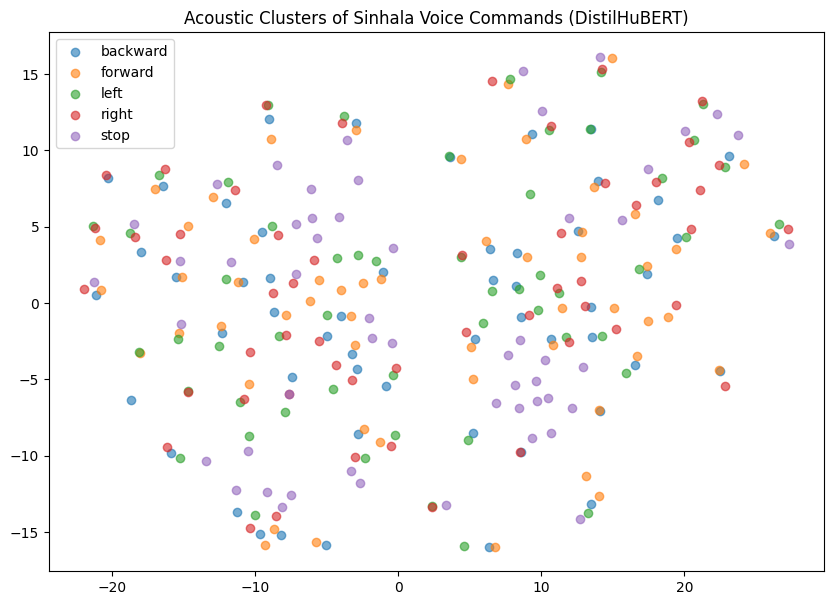

In [10]:
from transformers import AutoFeatureExtractor, HubertModel
from sklearn.manifold import TSNE
from tqdm.auto import tqdm
from typing import Optional
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
import librosa

# --- Safety Check ---
if 'DEVICE' not in locals(): DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
if 'LABELS' not in locals(): LABELS = ["backward", "forward", "left", "right", "stop"]

model_id = "ntu-spml/distilhubert"

print(f"--- Initializing Models (Device: {DEVICE}) ---")
try:
    feature_extractor = AutoFeatureExtractor.from_pretrained(model_id)
    hubert_model = HubertModel.from_pretrained(model_id).to(DEVICE)
    hubert_model.eval() # Set to evaluation mode
    print("Models loaded successfully.")
except Exception as e:
    print(f"Error loading models: {e}")
    feature_extractor, hubert_model = None, None

def load_audio(path: str, sr: int = 16000) -> Optional[np.ndarray]:
    try:
        audio, _ = librosa.load(path, sr=sr, mono=True)
        return audio.astype(np.float32)
    except Exception as e:
        print(f" [Warn] Could not load '{path}': {e}")
        return None

def extract_features_sequential(df, filename):
    feat_dir  = "/content/drive/MyDrive/2nd Year Research Data/feature extractor outputs"
    save_path = os.path.join(feat_dir, filename)
    os.makedirs(feat_dir, exist_ok=True)

    all_embeddings, all_labels = [], []
    print(f"\nProcessing {filename} sequentially...")

    for idx, row in tqdm(df.iterrows(), total=len(df)):
        audio = load_audio(row['path'])
        if audio is None: continue

        try:
            # Prepare input for the model
            inputs = feature_extractor(audio, sampling_rate=16000, return_tensors="pt").to(DEVICE)

            with torch.no_grad():
                outputs = hubert_model(**inputs)
                # Apply mean pooling over the sequence dimension (dim=1)
                # outputs.last_hidden_state shape: [1, sequence_length, 768]
                embedding = outputs.last_hidden_state.mean(dim=1).squeeze().cpu().numpy()

            all_embeddings.append(embedding)
            all_labels.append(LABELS.index(row['label']))

        except Exception as e:
            print(f" [Error] Failed on {row['path']}: {e}")

    if all_embeddings:
        features = {
            "embeddings": torch.tensor(np.array(all_embeddings), dtype=torch.float32),
            "labels": torch.tensor(all_labels, dtype=torch.long)
        }
        torch.save(features, save_path)
        print(f"Successfully saved features to {save_path}")
        return features
    return None

# --- Main Execution ---
if 'train_df' in locals() and hubert_model:
    train_features = extract_features_sequential(train_df, "train_features.pt")
    val_features   = extract_features_sequential(val_df,   "val_features.pt")
    test_features  = extract_features_sequential(test_df,  "test_features.pt")

    if train_features:
        print("\nGenerating Acoustic Visualization...")
        n_samples = len(train_features['embeddings'])
        # Perplexity adjustment for small datasets
        tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, n_samples-1))
        projs = tsne.fit_transform(train_features['embeddings'].numpy())

        plt.figure(figsize=(10, 7))
        for i, label in enumerate(LABELS):
            idx = np.where(train_features['labels'].numpy() == i)
            plt.scatter(projs[idx, 0], projs[idx, 1], label=label, alpha=0.6)

        plt.title("Acoustic Clusters of Sinhala Voice Commands (DistilHuBERT)")
        plt.legend()
        plt.show()

## step 4: Model Creation & Training (PyTorch)

*Building the lightweight classifier with architectures inspired by low-resource speech research.*

### 4.1 Layer-by-Layer Explanation of the MLP (768D Vector)
The custom network is designed to process DistilHuBERT acoustic features using robust classification practices found in the literature:

1. **Layer 1: Layer Normalization**
   - **Function:** Standardizes the 768-dimensional input features to improve training stability and ensure consistent gradients.

2. **Layer 2: Input Dropout**
   - **Parameter:** `p = 0.20`.
   - **Function:** Randomly masks 20% of the input acoustic features to force the model to learn redundant and robust representations.

3. **Layer 3: Hidden Dense Layer**
   - **Size:** 256 neurons.
   - **Activation:** `GELU` (Gaussian Error Linear Unit). A high-performance activation function that provides smoother gradients than ReLU.

4. **Layer 4: Hidden Dropout**
   - **Parameter:** `p = 0.40`.
   - **Function:** Stronger regularization (40% dropout) applied to the hidden features to prevent overfitting on the directional command dataset.

5. **Layer 5: Output Layer**
   - **Size:** 5 neurons (Forward, Backward, Left, Right, Stop).
   - **Function:** Produces raw logit scores for each class, which are converted to probabilities for prediction.

### 4.2 Hyperparameters for Model Fitting
These parameters are optimized for low-resource acoustic tasks:

*   **Optimizer:** `AdamW` (LR=0.0005, Weight Decay=0.01). Combines adaptive learning rates with decoupled weight decay for better generalization.
*   **Loss Function:** `Smoothed Focal Loss` (gamma=2.0, smoothing=0.1). Focuses learning on "hard" samples near acoustic boundaries while preventing over-confidence.
*   **Batch Size:** 64. Provides stable weight updates while maintaining memory efficiency.
*   **Epochs:** 100. Extended training time with Early Stopping (patience=15) to ensure the model reaches optimal convergence.

In [71]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR
from torch.utils.data import DataLoader, TensorDataset
import os
import pandas as pd

class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, reduction='mean', label_smoothing=0.1):
        super(FocalLoss, self).__init__()
        self.gamma = gamma
        self.reduction = reduction
        self.label_smoothing = label_smoothing

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(
            inputs,
            targets,
            reduction='none',
            label_smoothing=self.label_smoothing
        )
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss

        if self.reduction == 'mean':
            return focal_loss.mean()
        return focal_loss.sum()

# --- 4.1 Architecture Definition ---
class CommandClassifier(nn.Module):
    def __init__(self, input_dim=768, num_classes=5):
        super(CommandClassifier, self).__init__()
        self.network = nn.Sequential(
            nn.LayerNorm(input_dim),
            nn.Dropout(0.20),          # [UPDATED] Mask more input features to force redundancy
            nn.Linear(input_dim, 256),
            nn.GELU(),
            nn.Dropout(0.40),          # [UPDATED] Stronger hidden regularization
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.network(x)

# --- Path Definitions & Data Loading ---
feature_input_dir   = "/content/drive/MyDrive/2nd Year Research Data/feature extractor outputs"
training_output_dir = "/content/drive/MyDrive/2nd Year Research Data/Training Outputs"
os.makedirs(training_output_dir, exist_ok=True)

train_path   = os.path.join(feature_input_dir, "train_features.pt")
val_path     = os.path.join(feature_input_dir, "val_features.pt")
history_file = os.path.join(training_output_dir, "training_history.csv")

if os.path.exists(train_path) and os.path.exists(val_path):
    print(f"[CHECK] Pulling acoustic data from {feature_input_dir}...")
    train_data = torch.load(train_path)
    val_data   = torch.load(val_path)

    X_train, y_train = train_data['embeddings'], train_data['labels']
    X_val, y_val     = val_data['embeddings'], val_data['labels']

    BATCH_SIZE = 64
    train_dataset = TensorDataset(X_train, y_train)
    val_dataset   = TensorDataset(X_val, y_val)
    train_loader  = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    val_loader    = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"[INFO] Moving model to {DEVICE}...")

    model = CommandClassifier().to(DEVICE)

    print("[INFO] Using Smoothed Focal Loss to separate hard acoustic boundaries...")
    criterion = FocalLoss(gamma=2.0, label_smoothing=0.1)

    # [UPDATED] Massive increase to weight_decay to enforce a Maximum Margin boundary
    optimizer = optim.AdamW(
        model.parameters(),
        lr=0.0005,
        betas=(0.9, 0.999),
        weight_decay=0.01
    )

    scheduler = StepLR(optimizer, step_size=20, gamma=0.5)

    # --- Training Loop ---
    EPOCHS = 100
    patience = 15
    best_val_loss = float('inf')
    trigger_times = 0
    history_list = []

    print("--- Starting Training ---")
    for epoch in range(EPOCHS):
        model.train()
        train_loss = 0
        correct = 0

        for inputs, labels_batch in train_loader:
            inputs, labels_batch = inputs.to(DEVICE), labels_batch.to(DEVICE)

            optimizer.zero_grad()
            outputs = model(inputs)

            loss = criterion(outputs, labels_batch)

            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            correct += (predicted == labels_batch).sum().item()

        train_acc = correct / len(train_dataset)

        # Validation Phase
        model.eval()
        val_loss = 0
        correct = 0
        with torch.no_grad():
            for inputs, labels_batch in val_loader:
                inputs, labels_batch = inputs.to(DEVICE), labels_batch.to(DEVICE)
                outputs   = model(inputs)
                loss      = criterion(outputs, labels_batch)
                val_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                correct += (predicted == labels_batch).sum().item()

        val_acc = correct / len(val_dataset)
        val_loss_epoch = val_loss / len(val_loader)

        scheduler.step()

        metrics = {
            "epoch":      epoch + 1,
            "train_loss": train_loss / len(train_loader),
            "val_loss":   val_loss_epoch,
            "train_acc":  train_acc,
            "val_acc":    val_acc,
            "lr":         optimizer.param_groups[0]['lr']
        }
        history_list.append(metrics)
        pd.DataFrame(history_list).to_csv(history_file, index=False)

        print(f"Epoch {epoch+1:02d} | LR: {metrics['lr']:.6f} | Loss: {metrics['train_loss']:.3f} | Val Loss: {metrics['val_loss']:.3f} | Acc: {metrics['train_acc']:.3f} | Val Acc: {metrics['val_acc']:.3f}")

        if metrics['val_loss'] < best_val_loss:
            best_val_loss = metrics['val_loss']
            torch.save(model.state_dict(), os.path.join(training_output_dir, 'best_model.pth'))
            trigger_times = 0
        else:
            trigger_times += 1
            if trigger_times >= patience:
                print("[INFO] Early stopping triggered!")
                break
else:
    print(f"[ERROR] Could not find feature files in {feature_input_dir}")

[CHECK] Pulling acoustic data from /content/drive/MyDrive/2nd Year Research Data/feature extractor outputs...
[INFO] Moving model to cuda...
[INFO] Using Smoothed Focal Loss to separate hard acoustic boundaries...
--- Starting Training ---
Epoch 01 | LR: 0.000500 | Loss: 1.021 | Val Loss: 0.901 | Acc: 0.289 | Val Acc: 0.404
Epoch 02 | LR: 0.000500 | Loss: 0.843 | Val Loss: 0.782 | Acc: 0.455 | Val Acc: 0.649
Epoch 03 | LR: 0.000500 | Loss: 0.711 | Val Loss: 0.685 | Acc: 0.598 | Val Acc: 0.649
Epoch 04 | LR: 0.000500 | Loss: 0.617 | Val Loss: 0.594 | Acc: 0.654 | Val Acc: 0.719
Epoch 05 | LR: 0.000500 | Loss: 0.515 | Val Loss: 0.503 | Acc: 0.752 | Val Acc: 0.754
Epoch 06 | LR: 0.000500 | Loss: 0.453 | Val Loss: 0.432 | Acc: 0.756 | Val Acc: 0.825
Epoch 07 | LR: 0.000500 | Loss: 0.411 | Val Loss: 0.375 | Acc: 0.793 | Val Acc: 0.789
Epoch 08 | LR: 0.000500 | Loss: 0.322 | Val Loss: 0.334 | Acc: 0.835 | Val Acc: 0.772
Epoch 09 | LR: 0.000500 | Loss: 0.325 | Val Loss: 0.306 | Acc: 0.868 | V

## step 5: Deep Learning Evaluations

*Generating the standard ML metrics required to prove efficacy.*

1. **Learning Curves:** Plot the Epoch vs. Accuracy curve and Epoch vs. Loss curve.
2. 💡 **Crucial Addition - Confusion Matrix:** Pass your strictly isolated **Test Set** through the trained model. Plot a Confusion Matrix to see exactly where the model fails.
3. 💡 **Crucial Addition - Classification Report:** Calculate the Precision, Recall, and F1-Score for each of the 5 classes using the Test Set.

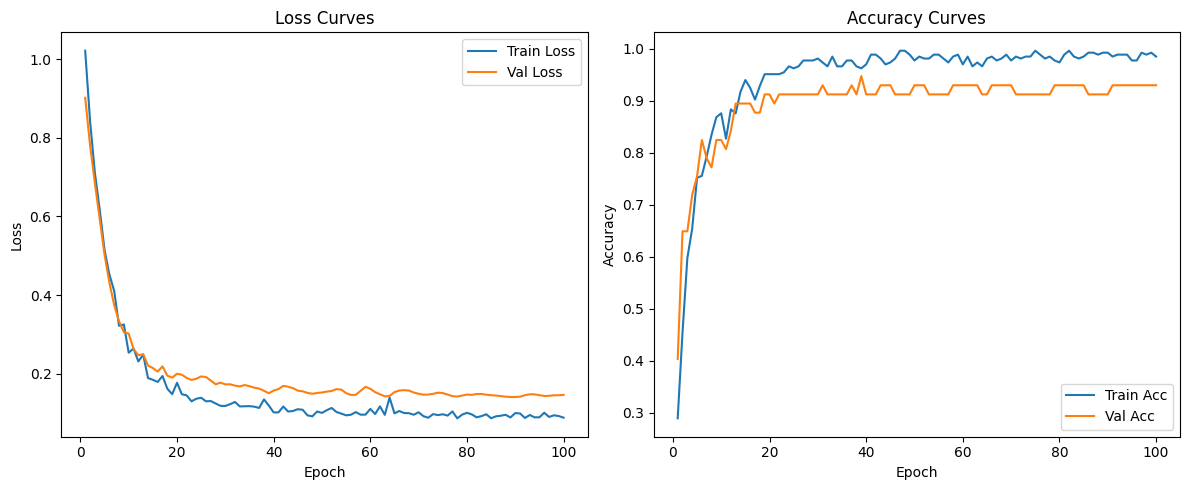


Classification Report (Test Set):
              precision    recall  f1-score   support

    backward       0.90      0.75      0.82        12
     forward       1.00      0.82      0.90        11
        left       0.62      0.91      0.74        11
       right       0.83      0.83      0.83        12
        stop       0.90      0.82      0.86        11

    accuracy                           0.82        57
   macro avg       0.85      0.83      0.83        57
weighted avg       0.85      0.82      0.83        57



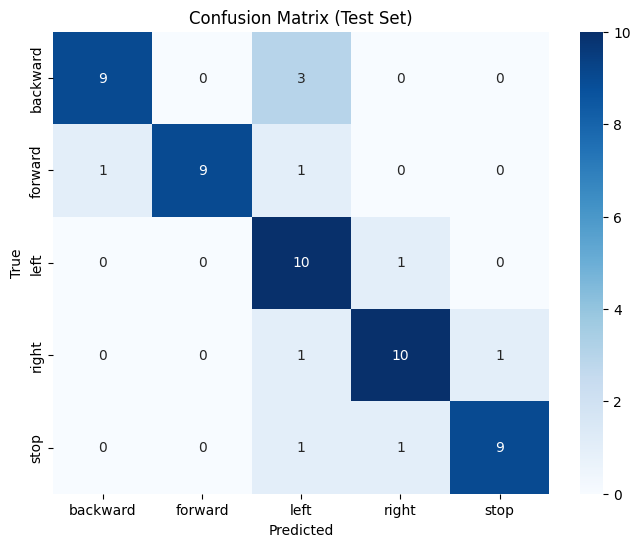

In [72]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import confusion_matrix, classification_report

feature_input_dir   = "/content/drive/MyDrive/2nd Year Research Data/feature extractor outputs"
training_output_dir = "/content/drive/MyDrive/2nd Year Research Data/Training Outputs"
history_file        = os.path.join(training_output_dir, "training_history.csv")
best_model_path     = os.path.join(training_output_dir, "best_model.pth")
test_path           = os.path.join(feature_input_dir,   "test_features.pt")

# 5.1 Learning Curves
if os.path.exists(history_file):
    history_df = pd.read_csv(history_file)

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history_df['epoch'], history_df['train_loss'], label='Train Loss')
    plt.plot(history_df['epoch'], history_df['val_loss'],   label='Val Loss')
    plt.title('Loss Curves')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history_df['epoch'], history_df['train_acc'], label='Train Acc')
    plt.plot(history_df['epoch'], history_df['val_acc'],   label='Val Acc')
    plt.title('Accuracy Curves')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print(f"[WARN] History file not found at {history_file}. Run training first.")

# 5.2 Confusion Matrix & Classification Report
if os.path.exists(best_model_path) and os.path.exists(test_path):
    # Fix #7: load test_features from disk if not already in memory
    if 'test_features' not in locals():
        test_features = torch.load(test_path, map_location=DEVICE, weights_only=True)
        print(f"[INFO] Loaded test_features from disk: {test_features['embeddings'].shape}")

    # Fix #6: instantiate model if not in memory, then load weights safely
    if 'model' not in locals():
        model = CommandClassifier().to(DEVICE)
    # Fix #8: add map_location + weights_only=True (state_dict has no lists)
    model.load_state_dict(torch.load(best_model_path, map_location=DEVICE, weights_only=True), strict=False)
    model.eval()

    test_loader = DataLoader(
        TensorDataset(test_features['embeddings'], test_features['labels']),
        batch_size=16
    )

    all_preds, all_true = [], []
    with torch.no_grad():
        for inputs, labels_batch in test_loader:
            inputs  = inputs.to(DEVICE)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_true.extend(labels_batch.numpy())

    print("\nClassification Report (Test Set):")
    print(classification_report(all_true, all_preds, target_names=LABELS))

    cm = confusion_matrix(all_true, all_preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=LABELS, yticklabels=LABELS, cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix (Test Set)')
    plt.show()
else:
    missing = []
    if not os.path.exists(best_model_path): missing.append('best_model.pth')
    if not os.path.exists(test_path):       missing.append('test_features.pt')
    print(f"[ERROR] Missing files: {missing}. Run Steps 3 and 4 first.")

## step 6: Predictions (The Sanity Check)

*Proving the system works on unseen data before integrating a microphone.*

1. **Isolated Inference Script:** Write a script that randomly selects **three** audio files from the Test Set.
2. **Full Pass-Through:** Run each audio file through the entire pipeline (DistilHuBERT → Loaded `.pth` Model).
3. **Result Output:** Print the Softmax probabilities alongside the True Label vs. Predicted Label to visually confirm success.

In [73]:
def predict_sample(sample_path, true_label):
    best_model_path = "/content/drive/MyDrive/2nd Year Research Data/Training Outputs/best_model.pth"
    if 'model' not in globals():
        globals()['model'] = CommandClassifier().to(DEVICE)
    if os.path.exists(best_model_path):
        model.load_state_dict(torch.load(best_model_path, map_location=DEVICE, weights_only=True), strict=False)
    audio = load_audio(sample_path)
    if audio is None: return

    # Prepare input for DistilHuBERT
    inputs = feature_extractor(audio, sampling_rate=16000, return_tensors="pt").to(DEVICE)

    model.eval()
    with torch.no_grad():
        # Extract acoustic features
        hubert_outputs = hubert_model(**inputs)
        embedding = hubert_outputs.last_hidden_state.mean(dim=1) # Shape: [1, 768]

        # Classify using the trained MLP
        outputs = model(embedding)
        probs = torch.softmax(outputs, dim=1)
        prob, predicted = torch.max(probs, 1)

    pred_label = LABELS[predicted.item()]
    print(f"Sample: {os.path.basename(sample_path)} | Pred: {pred_label} ({prob.item()*100:.2f}%) | True: {true_label}")

if 'test_df' in locals() and not test_df.empty:
    samples = test_df.sample(min(3, len(test_df)))
    for _, row in samples.iterrows():
        predict_sample(row['path'], row['label'])

Sample: right(26).wav | Pred: right (73.51%) | True: right
Sample: right(48).wav | Pred: stop (95.33%) | True: right
Sample: backward(60).wav | Pred: left (32.51%) | True: backward
